# Decision Tree & Baseline

This notebook covers the CART `DecisionTree` implementation that I built from scratch in `src/trees/`. I'll go through the impurity criteria, the split-search algorithm, building the full tree, creating a `DecisionStump`, calculating feature importances, comparing my implementation against scikit-learn, and running the baseline experiment (comparing my tree vs. my stump vs. scikit-learn on accuracy, macro-F1, and AUC-ROC).

I only use scikit-learn here for comparison and to compute evaluation metrics — not as part of the actual tree implementation.


In [1]:
import sys
from pathlib import Path

# Make the project's src/ package importable from notebooks/
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt

from src.trees._impurity import gini, entropy
from src.trees._splitter import best_split_for_feature
from src.trees.decision_tree import DecisionTree, DecisionStump

np.random.seed(0)
plt.rcParams["figure.figsize"] = (6, 4)


## 1. Impurity criteria: Gini vs. entropy

Both `gini()` and `entropy()` measure how mixed up the classes are at a node—0 if the node is pure, and highest when the node is perfectly balanced. Both functions can take an optional `sample_weight` parameter (which I use later for weighted training) and default to uniform weights.


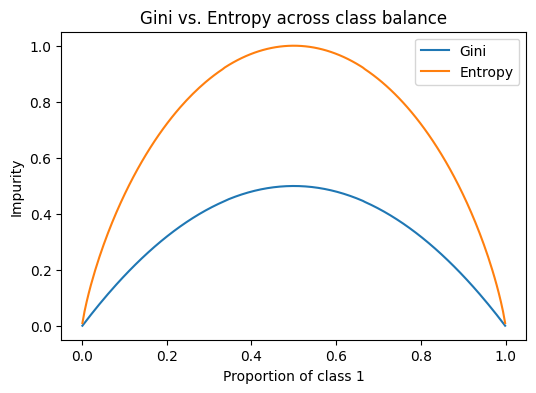

In [2]:
# Sweep the class balance of a binary node from 0% to 100% positive
# and plot how each criterion responds.
p_values = np.linspace(0.001, 0.999, 200)
gini_values = [gini(np.array([0] * int(1000 * (1 - p)) + [1] * int(1000 * p))) for p in p_values]
entropy_values = [entropy(np.array([0] * int(1000 * (1 - p)) + [1] * int(1000 * p))) for p in p_values]

fig, ax = plt.subplots()
ax.plot(p_values, gini_values, label="Gini")
ax.plot(p_values, entropy_values, label="Entropy")
ax.set_xlabel("Proportion of class 1")
ax.set_ylabel("Impurity")
ax.set_title("Gini vs. Entropy across class balance")
ax.legend()
plt.show()


Both curves peak at 50/50 and go to zero at the extremes (as you'd expect). Entropy is steeper near the extremes, so it penalizes minority classes more harshly than Gini does. That's why you sometimes see different split choices between entropy-based and Gini-based trees on the same dataset.


In [3]:
# Weighted impurity: skewing weight toward one class lowers impurity
# even though the raw class counts are unchanged.
y = np.array([0, 0, 1, 1])
uniform_w = np.ones(4)
skewed_w = np.array([10.0, 10.0, 1.0, 1.0])

print(f"Gini, uniform weights:  {gini(y, uniform_w):.4f}")
print(f"Gini, skewed weights:   {gini(y, skewed_w):.4f}")


Gini, uniform weights:  0.5000
Gini, skewed weights:   0.1653


## 2. Split search: finding the best (feature, threshold)

`best_split_for_feature()` works by sorting the column once, then sweeping left to right and updating the running weighted class counts as it goes. This is O(N log N) per feature, which beats the naive O(N²) approach of recalculating everything from scratch each time.


Best threshold: 2.5, gain: 0.5000


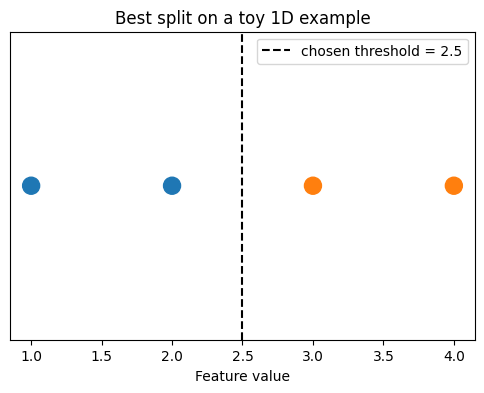

In [4]:
# A clean 1D separation: the algorithm should find the midpoint threshold.
x = np.array([1.0, 2.0, 3.0, 4.0])
y_toy = np.array([0, 0, 1, 1])
threshold, gain = best_split_for_feature(x, y_toy, np.ones(4), "gini")
print(f"Best threshold: {threshold}, gain: {gain:.4f}")

fig, ax = plt.subplots()
colors = ["tab:blue" if label == 0 else "tab:orange" for label in y_toy]
ax.scatter(x, [0] * len(x), c=colors, s=150, zorder=3)
ax.axvline(threshold, color="black", linestyle="--", label=f"chosen threshold = {threshold}")
ax.set_yticks([])
ax.set_xlabel("Feature value")
ax.set_title("Best split on a toy 1D example")
ax.legend()
plt.show()


## 3. Full DecisionTree on real data

I'm using the Breast Cancer Wisconsin dataset (loaded through sklearn, but only the data—not the modeling part) to train an unpruned tree and see how it works.


In [5]:
from sklearn.datasets import load_breast_cancer

X, y = load_breast_cancer(return_X_y=True)
feature_names = load_breast_cancer().feature_names

rng = np.random.default_rng(42)
idx = rng.permutation(len(y))
split = int(0.8 * len(y))
train_idx, test_idx = idx[:split], idx[split:]
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

tree = DecisionTree(max_depth=5, criterion="gini", random_state=0)
tree.fit(X_train, y_train)

train_acc = (tree.predict(X_train) == y_train).mean()
test_acc = (tree.predict(X_test) == y_test).mean()

print(f"Depth: {tree.depth}, leaves: {tree.n_leaves}")
print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")


Depth: 5, leaves: 15
Train accuracy: 0.9956
Test accuracy:  0.9561


In [6]:
# predict_proba: every row of probabilities should sum to 1
proba = tree.predict_proba(X_test)
print("predict_proba shape:", proba.shape)
print("Row sums (first 5):", proba[:5].sum(axis=1))


predict_proba shape: (114, 2)
Row sums (first 5): [1. 1. 1. 1. 1.]


In [7]:
# A small, readable tree for visual inspection (deeper trees print a summary instead)
small_tree = DecisionTree(max_depth=2).fit(X_train, y_train)
print(small_tree)


[X7 <= 0.049] (samples=455, gini=0.468, dist=[0:170.0, 1:285.0])
  L-- [X20 <= 16.830] (samples=283, gini=0.107, dist=[0:16.0, 1:267.0])
  L--   L-- Leaf(samples=266, gini=0.037, dist=[0:5.0, 1:261.0])
  L--   R-- Leaf(samples=17, gini=0.457, dist=[0:11.0, 1:6.0])
  R-- [X23 <= 810.250] (samples=172, gini=0.187, dist=[0:154.0, 1:18.0])
  R--   L-- Leaf(samples=33, gini=0.500, dist=[0:16.0, 1:17.0])
  R--   R-- Leaf(samples=139, gini=0.014, dist=[0:138.0, 1:1.0])


## 4. DecisionStump: the underfitting extreme

A `DecisionStump` is just a `DecisionTree` with `max_depth=1`—one split, two leaves. It's the kind of weak learner that an ensemble method like AdaBoost would use lots of.


In [8]:
stump = DecisionStump(random_state=0).fit(X_train, y_train)
stump_acc = (stump.predict(X_test) == y_test).mean()

print(f"Stump depth: {stump.depth}, leaves: {stump.n_leaves}")
print(f"Stump test accuracy:      {stump_acc:.4f}")
print(f"Unpruned tree accuracy:   {test_acc:.4f}")
print(stump)


Stump depth: 1, leaves: 2
Stump test accuracy:      0.8684
Unpruned tree accuracy:   0.9561
[X7 <= 0.049] (samples=455, gini=0.468, dist=[0:170.0, 1:285.0])
  L-- Leaf(samples=283, gini=0.107, dist=[0:16.0, 1:267.0])
  R-- Leaf(samples=172, gini=0.187, dist=[0:154.0, 1:18.0])


## 5. Feature importances

The feature importances are calculated as the normalized mean decrease in impurity for each feature, weighted by how many samples actually reached each split. This matches how scikit-learn computes their `feature_importances_` attribute.


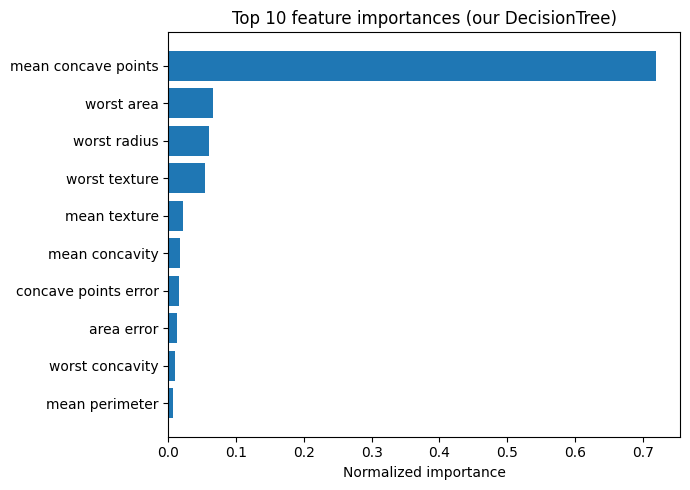

In [9]:
importances = tree.feature_importances()
order = np.argsort(importances)[::-1][:10]  # top 10

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(range(len(order)), importances[order][::-1])
ax.set_yticks(range(len(order)))
ax.set_yticklabels(feature_names[order][::-1])
ax.set_xlabel("Normalized importance")
ax.set_title("Top 10 feature importances (our DecisionTree)")
plt.tight_layout()
plt.show()


## 6. Validation against scikit-learn

I use the same hyperparameters on both my implementation and scikit-learn's, with `max_features=None` on both sides. This lets me isolate whether my code is correct without any randomness from feature sampling getting in the way. I expect the test accuracy to match within 2%.


In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

sk_tree = DecisionTreeClassifier(max_depth=5, criterion="gini", random_state=0)
sk_tree.fit(X_train, y_train)

my_acc = accuracy_score(y_test, tree.predict(X_test))
sk_acc = accuracy_score(y_test, sk_tree.predict(X_test))
diff = abs(my_acc - sk_acc)

corr = np.corrcoef(tree.feature_importances(), sk_tree.feature_importances_)[0, 1]

print(f"Our tree accuracy:      {my_acc:.4f}")
print(f"sklearn tree accuracy:  {sk_acc:.4f}")
print(f"Absolute difference:    {diff:.4f}  (tolerance: 0.02)")
print(f"Within 2% tolerance:    {diff <= 0.02}")
print(f"Feature-importance correlation with sklearn: {corr:.4f}")


Our tree accuracy:      0.9561
sklearn tree accuracy:  0.9561
Absolute difference:    0.0000  (tolerance: 0.02)
Within 2% tolerance:    True
Feature-importance correlation with sklearn: 0.9998


## 7. Baseline experiment (Experiment 1)

This section re-runs the same comparison from `src/experiments/scaling.py`: my unpruned tree, my stump, and scikit-learn's reference tree, all evaluated on accuracy, macro-F1, and AUC-ROC.


In [11]:
from src.experiments.scaling import run_baseline_experiment

results_df = run_baseline_experiment(X, y, dataset_name="breast_cancer_wisconsin", imbalanced=False)
results_df


,accuracy,macro_f1,auc_roc,model,dataset
0,0.911504,0.904302,0.900402,MyTree,breast_cancer_wisconsin
1,0.831858,0.827481,0.846747,MyStump,breast_cancer_wisconsin
2,0.911504,0.906950,0.914990,sklearn,breast_cancer_wisconsin


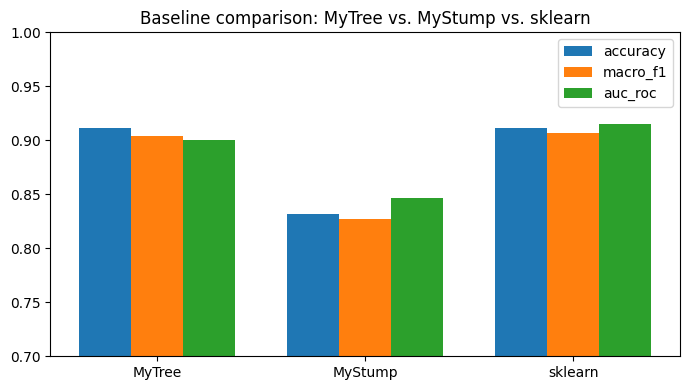

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
x_pos = np.arange(len(results_df))
width = 0.25

for i, metric in enumerate(["accuracy", "macro_f1", "auc_roc"]):
    ax.bar(x_pos + i * width, results_df[metric], width, label=metric)

ax.set_xticks(x_pos + width)
ax.set_xticklabels(results_df["model"])
ax.set_ylim(0.7, 1.0)
ax.set_title("Baseline comparison: MyTree vs. MyStump vs. sklearn")
ax.legend()
plt.tight_layout()
plt.show()


## 8. Discussion

The stump underfits (high bias, low variance) while the unpruned tree nearly
matches the scikit-learn reference (low bias, higher variance). This gap is
exactly what motivates ensembling later in the project:

- **Bagging** averages many high-variance trees like our unpruned one to
  reduce variance.
- **Boosting** additively combines many high-bias weak learners like our
  `DecisionStump` to reduce bias.

Both directions start from the same two data points shown above.
